# 04 — Coordinate frames: Haslam, ARCADE 2 and TRIS into one frame

TRIS is equatorial (RA/Dec, LST-based). Haslam and ARCADE 2 have to be in the same frame
before any pixel of one is compared with a pixel of another. This notebook works in order:

1. **What each input actually declares**, read from its own header, not from convention.
   Each declaration is then checked against the sky.
2. **Pixel ordering**, because healpy's rotations need RING.
3. **Which rotation method, for each map**, following healpy's own guidance and checked
   by a round trip.
4. **Sanity check.** Do known sources land where the literature puts them after rotation?
5. **ARCADE 2's exact-zero mask, checked again after rotation.**

It stops there. Beam matching and smoothing are a separate step. The rotation code is
in `src/moonrunes/frames.py`.

In [1]:
%matplotlib inline
import os
os.environ["TQDM_DISABLE"] = "1"
import json
import sys
import warnings
from pathlib import Path

import numpy as np
import healpy as hp
import matplotlib.pyplot as plt
import astropy.units as u
from astropy.coordinates import SkyCoord

REPO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO / "src"))
warnings.filterwarnings("ignore", category=UserWarning)
plt.rcParams.update({"figure.dpi": 110, "font.size": 9, "figure.facecolor": "white"})

from moonrunes.config import load_config
from moonrunes import frames
from moonrunes.stage1_tris_maps import import_limtod_tris
from moonrunes.stage2_beam_matching import observed_mask

config = load_config(REPO / "configs" / "run_config.yaml")
tris = import_limtod_tris(config)
FITS = {
    "Haslam 408 MHz":    config.resolve_path("paths.haslam_map_fits"),
    "ARCADE 2 3.15 GHz": config.resolve_path("paths.arcade2_map_3150"),
    "ARCADE 2 3.41 GHz": config.resolve_path("paths.arcade2_map_3410"),
}
ARCADE = {k: v for k, v in FITS.items() if k.startswith("ARCADE")}
STAGE1 = REPO / "outputs" / "stage1_nside8"

---
## 1. What each input declares

Every HDU is scanned for `COORDSYS` (the HEALPix standard) and for `SKYCOORD`. This matters
because ARCADE 2 does **not** write `COORDSYS`, which is why it has so far been recorded as
"frame unstated". It does, however, write `SKYCOORD`.

In [2]:
print(f"{'file':<20}{'frame':>7}  {'stated as':<34}{'ORDERING':>9}{'NSIDE':>7}")
DECLARED = {}
for name, path in FITS.items():
    d = frames.declared_frame(path)
    DECLARED[name] = d
    stated = ", ".join(f"HDU{s['hdu']} {s['keyword']}={s['value']!r}"
                       for s in d["statements"]) or "(nothing)"
    print(f"{name:<20}{str(d['frame']):>7}  {stated:<34}{d['ordering']:>9}{d['nside']:>7}")

# TRIS: stage 1 writes .npz + JSON, not FITS.  Look for anything frame-like in both.
manifest = json.loads((STAGE1 / "stage1_manifest.json").read_text())
npz = np.load(next(STAGE1.glob("*.npz")))
hits = [k for k in list(npz.files) + list(json.dumps(manifest).split('"'))
        if any(w in k.lower() for w in ("coord", "frame", "galactic", "equatorial", "icrs"))]
print(f"\nTRIS stage 1       arrays {npz.files}")
print(f"                   frame-like keys in npz or manifest: {hits or 'none'}")
print("                   ra_deg is present: the grid is indexed by right ascension")

file                  frame  stated as                          ORDERING  NSIDE
Haslam 408 MHz            G  HDU1 COORDSYS='GALACTIC'               RING    512
ARCADE 2 3.15 GHz         G  HDU0 SKYCOORD='Galactic', HDU1 SKYCOORD='Galactic'   NESTED     16
ARCADE 2 3.41 GHz         G  HDU0 SKYCOORD='Galactic', HDU1 SKYCOORD='Galactic'   NESTED     16

TRIS stage 1       arrays ['nside', 'pixel_indices', 'band_mask', 'freq_mhz', 'effective_freq_mhz', 'ref_freq_mhz', 'sky_k', 'sky_sigma_k', 'prior_mean_k', 'prior_sigma_k', 'truth_k', 'zero_level_k', 'zero_level_sigma_k', 'zero_level_prior_sigma_k', 'ra_deg', 'data_k', 'residual_k', 'beam_coverage', 'sky_full_k', 'sky_sigma_full_k']
                   frame-like keys in npz or manifest: none
                   ra_deg is present: the grid is indexed by right ascension


**What the headers say.** Haslam and both ARCADE 2 files declare **Galactic**, and none of the
HDUs contradicts another. The stage 1 TRIS product declares **nothing**. It is equatorial by
construction (limTOD sets the boresight to `RA = LST, dec = site latitude` and builds its
operator on an equatorial pixel grid), but no file records that.

A header is a label, so each label is tested against the sky next.

### TRIS: does the ring peak where the Galactic plane crosses dec +42°?

astropy's frame transforms are independent of healpy's rotation matrices, so astropy gives
the right ascensions at which b = 0 crosses the ring's declination. The ring's own brightest
samples should sit there.

ring dec 42.43°: b = 0 at RA 74.9° (l = 164°), 310.8° (l = 82°)
600 MHz ring: brightest sample at RA 305.8° (28.19 K)
820 MHz ring: brightest sample at RA 305.8° (13.57 K)


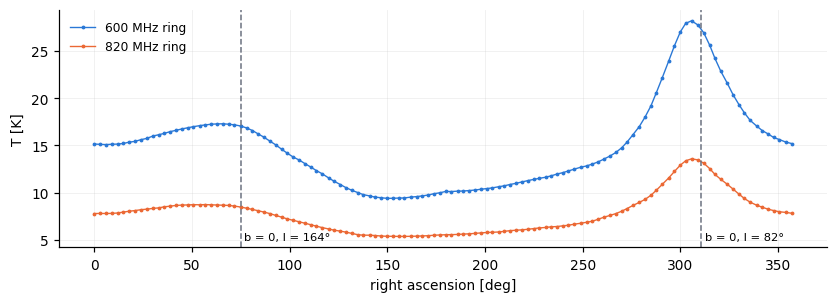

In [3]:
dec_ring = tris.TRIS_SITE_LATITUDE_DEG
ra_grid = np.arange(0, 360, 0.05)
b_grid = SkyCoord(ra=ra_grid * u.deg, dec=np.full_like(ra_grid, dec_ring) * u.deg).galactic.b.deg
crossings = ra_grid[np.flatnonzero(np.diff(np.sign(b_grid)))]
l_cross = SkyCoord(ra=crossings * u.deg, dec=[dec_ring] * len(crossings) * u.deg).galactic.l.deg
print(f"ring dec {dec_ring:.2f}°: b = 0 at RA " +
      ", ".join(f"{r:.1f}° (l = {l:.0f}°)" for r, l in zip(crossings, l_cross)))

ARCHIVE = config.resolve_path("paths.tris_archive_dir")
fig, ax = plt.subplots(figsize=(9, 2.8))
for freq, colour in ((600, "#2a78d6"), (820, "#eb6834")):
    ring = tris.read_tris_ring(ARCHIVE / f"TRIS_absolute_{freq}.txt")
    ra, t = np.asarray(ring.ra_deg), np.asarray(ring.temperature_k)
    print(f"{freq} MHz ring: brightest sample at RA {ra[np.argmax(t)]:.1f}° ({t.max():.2f} K)")
    ax.plot(ra, t, ".-", ms=3, lw=0.9, color=colour, label=f"{freq} MHz ring")
for r, l in zip(crossings, l_cross):
    ax.axvline(r, color="#6b7280", ls="--", lw=1)
    ax.text(r + 2, ax.get_ylim()[0] + 0.5, f"b = 0, l = {l:.0f}°", fontsize=7.5, va="bottom")
ax.set_xlabel("right ascension [deg]"); ax.set_ylabel("T [K]")
ax.grid(alpha=0.18, lw=0.6); ax.legend(fontsize=8, frameon=False, loc="upper left")
for side in ("top", "right"):
    ax.spines[side].set_visible(False)
plt.show()

The ring's brightest sample, at both frequencies, is 5° from the Cygnus crossing
(l ≈ 82°). That is where the Cygnus X complex actually sits, and 5° is well inside an 18°
beam. So the TRIS RA axis is genuinely equatorial, and **TRIS needs no rotation**.

One residual caveat: the archive does not state an epoch. RA = LST is epoch-of-date, and
healpy's `C` is J2000. Precession is about 0.014° per year, so a decade is 0.14°. That is
negligible against 3° samples and 7° pixels, but it is recorded here rather than assumed away.

### Haslam and ARCADE 2: is the bright emission at low |b| in the files' own frame?

If a file really is Galactic, its brightest pixels sit on b ≈ 0 when read in its own
frame. If it were equatorial, reading it as Galactic would scatter them.

In [4]:
for name, path in FITS.items():
    sky = hp.read_map(path, field=0)
    valid = observed_mask(sky, "zeros" if name.startswith("ARCADE") else "full")
    idx = np.flatnonzero(valid)
    top = idx[np.argsort(sky[idx])[-20:]]
    lon, lat = hp.pix2ang(hp.get_nside(sky), top, lonlat=True)
    # the same pixels, if the file were in fact equatorial
    b_if_eq = SkyCoord(ra=lon * u.deg, dec=lat * u.deg).galactic.b.deg
    print(f"{name:<18} 20 brightest pixels: median |lat| read as Galactic {np.median(np.abs(lat)):5.1f}°"
          f"   ...as if equatorial, median |b| {np.median(np.abs(b_if_eq)):5.1f}°")

Haslam 408 MHz     20 brightest pixels: median |lat| read as Galactic   2.1°   ...as if equatorial, median |b|   7.0°
ARCADE 2 3.15 GHz  20 brightest pixels: median |lat| read as Galactic   4.8°   ...as if equatorial, median |b|  50.8°
ARCADE 2 3.41 GHz  20 brightest pixels: median |lat| read as Galactic   4.8°   ...as if equatorial, median |b|  50.6°


Both readings agree with the headers. The brightest emission sits on the Galactic plane in
each file's own frame. Read as equatorial, it would move off the plane by a median of about
50° for ARCADE 2. For Haslam the move is only about 7°, because its brightest pixels are Cas A
and the Galactic-centre region, and those happen to land near the plane either way. The
decisive test for Haslam is therefore the landmark check in section 4.
All three FITS maps need **Galactic → equatorial** (`hp.Rotator(coord=['G', 'C'])`).

---
## 2. Pixel ordering

healpy's rotations index pixels in RING. ARCADE 2 is stored NESTED. `hp.read_map` reads
`ORDERING` and reorders to RING by default, which this pipeline relies on. That is checked
here rather than trusted.

In [5]:
for name, path in FITS.items():
    stored = hp.read_map(path, nest=None)          # exactly as on disk
    default = hp.read_map(path)                    # what the pipeline reads
    order = DECLARED[name]["ordering"]
    expected = hp.reorder(stored, n2r=True) if order == "NESTED" else stored
    print(f"{name:<18} on disk {order:<7} -> hp.read_map gives RING: "
          f"{np.array_equal(default, expected)}")
print("\nEvery consumer (stage 2's load_input_map included) reads through hp.read_map,")
print("so the rotated maps stay RING and nothing converts back to NESTED.")

Haslam 408 MHz     on disk RING    -> hp.read_map gives RING: True
ARCADE 2 3.15 GHz  on disk NESTED  -> hp.read_map gives RING: True
ARCADE 2 3.41 GHz  on disk NESTED  -> hp.read_map gives RING: True

Every consumer (stage 2's load_input_map included) reads through hp.read_map,
so the rotated maps stay RING and nothing converts back to NESTED.


---
## 3. Which rotation, per map

healpy's documentation does not choose by nside. It chooses by two properties of the map:

* `rotate_map_alms`: *"generally the best strategy to rotate/change reference frame of
  maps. If the input map is band-limited … the map rotation will be invertible."*
* `rotate_map_pixel`: *"A case where pixel space rotation is better is for heavily masked
  maps where the spherical harmonics transform is not well defined … Due to interpolation,
  this function generally suppresses the signal at high angular scales."*

| map | nside | pixel | beam | mask | → method |
|---|---|---|---|---|---|
| Haslam | 512 | 0.11° | 0.93° | none | harmonic: band-limited, full sky |
| ARCADE 2 | 16 | 3.7° | 11.6° | 93% exact zero | pixel: heavily masked |

For Haslam the choice is tested directly with a G → C → G round trip, which would return
the input exactly for a perfect rotation.

In [6]:
haslam = hp.read_map(FITS["Haslam 408 MHz"])
to_g = hp.Rotator(coord=["C", "G"])
haslam_eq = frames.rotate_full_sky(haslam)                     # harmonic
trip_alm = to_g.rotate_map_alms(haslam_eq) - haslam
trip_pix = to_g.rotate_map_pixel(hp.Rotator(coord=["G", "C"]).rotate_map_pixel(haslam)) - haslam
print(f"{'Haslam G->C->G':<16}{'rms [K]':>9}{'max |Δ| [K]':>13}{'rms / map rms':>15}")
for label, d in (("harmonic", trip_alm), ("pixel", trip_pix)):
    print(f"{label:<16}{d.std():9.3f}{np.abs(d).max():13.1f}{d.std() / haslam.std():15.1e}")
print(f"\nrotated map: min {haslam_eq.min():.2f} K (input {haslam.min():.2f} K), "
      f"max {haslam_eq.max():.0f} K (input {haslam.max():.0f} K)")

Haslam G->C->G    rms [K]  max |Δ| [K]  rms / map rms
harmonic            0.080         33.0        2.1e-03
pixel               0.525        311.4        1.3e-02

rotated map: min 11.02 K (input 10.98 K), max 4863 K (input 4779 K)


The harmonic route is about 6× better in rms and 10× better in the worst pixel. The pixel
route loses peak brightness on compact sources through bilinear interpolation. The
harmonic route overshoots the brightest source (Cas A) by about 2%, which is Gibbs ringing
at a near-point source. It stays positive everywhere, and the map is about to be smoothed
to a 23° beam. **Haslam: harmonic.**

---
## 4. Sanity check: do known sources land where the literature says?

Three compact, bright 408 MHz sources, at their literature ICRS positions:

| source | RA | Dec | reference |
|---|---|---|---|
| Sgr A* (the Galactic centre) | 17h45m40.04s | −29°00′28.1″ | Reid & Brunthaler 2004, ApJ 616, 872 |
| Cas A | 23h23m24s | +58°48′54″ | SIMBAD |
| Tau A (Crab) | 05h34m31.94s | +22°00′52.2″ | SIMBAD |

In the **rotated** map, the brightest pixel within 5° of each position should be at
that position, to within about a beam (0.93°). The **unrotated** map, read as though it
were already equatorial, is the control. There the search should find nothing special.

In [7]:
LANDMARKS = {
    "Sgr A* (Galactic centre)": (266.41683, -29.00781),
    "Cas A":                    (350.85000, +58.81500),
    "Tau A (Crab)":             (83.63308, +22.01450),
}
SEARCH_DEG, BEAM_DEG = 5.0, 0.9333
print(f"{'':<26}{'':<12}{'peak RA':>9}{'peak Dec':>10}{'T [K]':>9}{'offset':>9}{'in beams':>10}  verdict")
CHECK = {}
for label, sky in (("rotated", haslam_eq), ("unrotated", haslam)):
    for src, r in frames.source_offsets_deg(sky, LANDMARKS, SEARCH_DEG).items():
        ok = r["offset_deg"] < BEAM_DEG
        CHECK[label, src] = ok
        print(f"{src:<26}{label:<12}{r['peak_lon_deg']:9.2f}{r['peak_lat_deg']:+10.2f}"
              f"{r['peak_k']:9.0f}{r['offset_deg']:8.2f}°{r['offset_deg'] / BEAM_DEG:10.2f}  "
              f"{'AT LITERATURE POSITION' if ok else 'not there'}")
peak = np.argmax(haslam_eq)
print(f"\nglobal maximum of the rotated map: RA {hp.pix2ang(512, peak, lonlat=True)[0]:.2f}°, "
      f"Dec {hp.pix2ang(512, peak, lonlat=True)[1]:+.2f}°  (Cas A)")

# The whole plane, not just three points: astropy's b for every rotated pixel.
ra_pix, dec_pix = hp.pix2ang(512, np.arange(haslam_eq.size), lonlat=True)
b_pix = SkyCoord(ra=ra_pix * u.deg, dec=dec_pix * u.deg).galactic.b.deg
print(f"median T at astropy |b| < 2°: rotated {np.median(haslam_eq[np.abs(b_pix) < 2]):.1f} K, "
      f"unrotated {np.median(haslam[np.abs(b_pix) < 2]):.1f} K   "
      f"(|b| > 60°: {np.median(haslam_eq[np.abs(b_pix) > 60]):.1f} K)")
assert all(CHECK["rotated", s] for s in LANDMARKS), "a landmark is not where it should be"
assert not any(CHECK["unrotated", s] for s in LANDMARKS), "the control should fail"

                                        peak RA  peak Dec    T [K]   offset  in beams  verdict
Sgr A* (Galactic centre)  rotated        266.48    -29.06     1919    0.08°      0.08  AT LITERATURE POSITION
Cas A                     rotated        350.76    +58.92     4863    0.11°      0.12  AT LITERATURE POSITION
Tau A (Crab)              rotated         83.50    +21.94      342    0.15°      0.16  AT LITERATURE POSITION
Sgr A* (Galactic centre)  unrotated      264.46    -24.62       20    4.72°      5.05  not there
Cas A                     unrotated      356.98    +55.49       29    4.70°      5.03  not there
Tau A (Crab)              unrotated       86.84    +18.60       39    4.54°      4.87  not there

global maximum of the rotated map: RA 350.76°, Dec +58.92°  (Cas A)


median T at astropy |b| < 2°: rotated 71.1 K, unrotated 23.4 K   (|b| > 60°: 19.6 K)


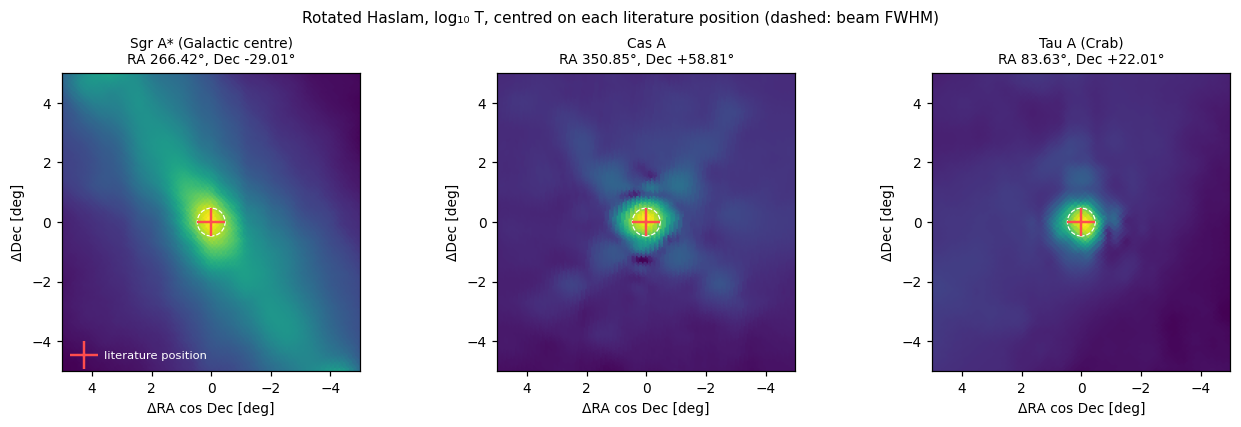

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.8))
for ax, (src, (ra0, dec0)) in zip(axes, LANDMARKS.items()):
    img = hp.gnomview(haslam_eq, rot=[ra0, dec0], reso=3.0, xsize=200, return_projected_map=True,
                      no_plot=True)
    half = 200 * 3.0 / 60 / 2
    ax.imshow(np.log10(img), origin="lower", cmap="viridis",
              extent=[half, -half, -half, half])       # RA increases to the left
    ax.plot(0, 0, "+", color="#ff4d4d", ms=18, mew=1.6, label="literature position")
    ax.add_patch(plt.Circle((0, 0), BEAM_DEG / 2, fill=False, color="w", lw=0.8, ls="--"))
    ax.set_title(f"{src}\nRA {ra0:.2f}°, Dec {dec0:+.2f}°", fontsize=9)
    ax.set_xlabel("ΔRA cos Dec [deg]"); ax.set_ylabel("ΔDec [deg]")
axes[0].legend(fontsize=7.5, loc="lower left", frameon=False, labelcolor="w")
fig.suptitle("Rotated Haslam, log₁₀ T, centred on each literature position (dashed: beam FWHM)",
             fontsize=10)
fig.tight_layout()
plt.show()

---
## 5. ARCADE 2: does the exact-zero mask survive the rotation?

`rotate_map_pixel` interpolates bilinearly over four neighbours. At the mask edge those
include zeros, so a plain rotation averages real 3 K sky with the 0 K fill and produces
pixels that are neither data nor mask. `frames.rotate_masked` rotates the zero-filled data
and the binary mask separately and divides one by the other. Each output pixel is then a
weighted mean over observed neighbours only. Pixels where less than half the interpolation
weight was observed are marked unobserved (the same 0.5 as stage 2's `weight_floor`).

Checks, on each band:

* no exact zeros and no non-finite values inside the rotated mask;
* every rotated value lies inside the original observed range. A zero leaking in would
  drag some below the minimum;
* the observed area is preserved, since a rotation preserves area;
* the mask is rebuilt independently from the `N_OBS` column and must agree;
* stage 2's own `observed_mask(..., "zeros")` reads the rotated map correctly;
* the plain rotation is shown too, to prove these checks can detect the failure.

In [9]:
haslam_eq_16 = hp.ud_grade(haslam_eq, 16)
ROTATED = {}
for name, path in ARCADE.items():
    t, n_obs = hp.read_map(path, field=0), hp.read_map(path, field=1)
    obs = observed_mask(t, "zeros")
    assert np.array_equal(obs, n_obs > 0), "zeros and N_OBS disagree before rotation"
    rot, obs_r, weight = frames.rotate_masked(t, obs)
    _, obs_from_nobs, _ = frames.rotate_masked(n_obs, n_obs > 0)
    naive = hp.Rotator(coord=["G", "C"]).rotate_map_pixel(t)
    ROTATED[name] = dict(t=t, obs=obs, rot=rot, obs_r=obs_r, weight=weight, naive=naive)

    inside = rot[obs_r]
    lo, hi = t[obs].min(), t[obs].max()
    leaked = (naive > 0) & (naive < lo)
    checks = {
        "no exact zeros inside mask":        int((inside == 0).sum()) == 0,
        "all finite inside mask":            bool(np.all(np.isfinite(inside))),
        "values inside original range":      bool(lo <= inside.min() and inside.max() <= hi),
        "N_OBS-derived mask agrees":         bool(np.array_equal(obs_r, obs_from_nobs)),
        "stage 2 observed_mask reads it":    bool(np.array_equal(observed_mask(rot, "zeros"), obs_r)),
    }
    print(f"{name}: observed {obs.sum()} -> {obs_r.sum()} pixels; range "
          f"[{lo:.4f}, {hi:.4f}] -> [{inside.min():.4f}, {inside.max():.4f}] K; "
          f"{int((weight[obs_r] < 0.999).sum())} edge pixels renormalised")
    for check, ok in checks.items():
        print(f"    {'PASS' if ok else 'FAIL'}  {check}")
    print(f"    plain rotate_map_pixel, for contrast: {leaked.sum()} pixels dragged below "
          f"{lo:.2f} K by the zero fill (lowest {naive[leaked].min():.1e} K)")

    back, obs_back, _ = frames.rotate_masked(rot, obs_r, frames=("C", "G"))
    both = obs & obs_back
    corr = np.corrcoef(rot[obs_r], haslam_eq_16[obs_r])[0, 1]
    corr_control = np.corrcoef(t[obs], haslam_eq_16[obs])[0, 1]
    print(f"    C->G round trip: rms {1e3 * np.std(back[both] - t[both]):.1f} mK "
          f"against a {1e3 * t[obs].std():.0f} mK signal rms")
    print(f"    correlation with rotated Haslam: {corr:.3f} rotated, "
          f"{corr_control:.3f} left unrotated\n")
    assert all(checks.values()), name

ARCADE 2 3.15 GHz: observed 220 -> 220 pixels; range [2.8024, 3.2259] -> [2.8033, 3.2178] K; 82 edge pixels renormalised
    PASS  no exact zeros inside mask
    PASS  all finite inside mask
    PASS  values inside original range
    PASS  N_OBS-derived mask agrees
    PASS  stage 2 observed_mask reads it
    plain rotate_map_pixel, for contrast: 158 pixels dragged below 2.80 K by the zero fill (lowest 2.5e-05 K)
    C->G round trip: rms 7.8 mK against a 85 mK signal rms
    correlation with rotated Haslam: 0.954 rotated, -0.081 left unrotated

ARCADE 2 3.41 GHz: observed 232 -> 234 pixels; range [2.7760, 3.1709] -> [2.7808, 3.1613] K; 83 edge pixels renormalised
    PASS  no exact zeros inside mask
    PASS  all finite inside mask
    PASS  values inside original range
    PASS  N_OBS-derived mask agrees
    PASS  stage 2 observed_mask reads it
    plain rotate_map_pixel, for contrast: 156 pixels dragged below 2.78 K by the zero fill (lowest 2.4e-05 K)
    C->G round trip: rms 7.2 mK 

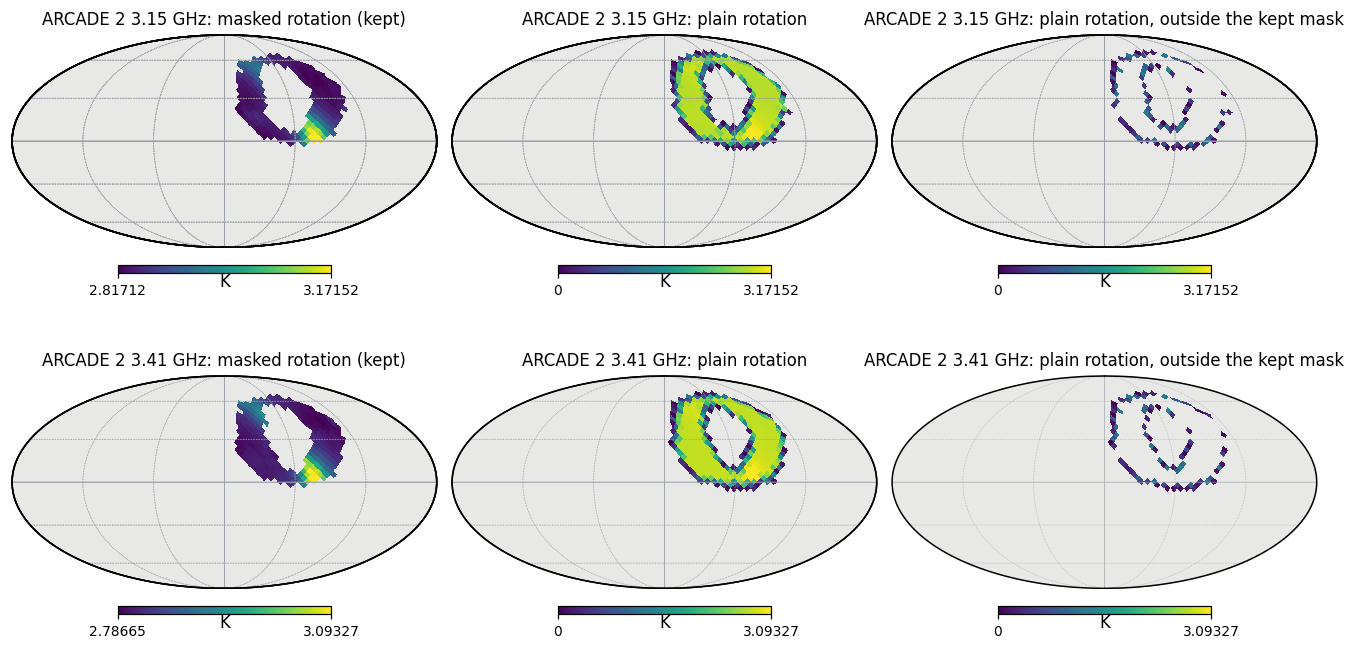

In [10]:
fig = plt.figure(figsize=(12, 6.2))
for row, (name, r) in enumerate(ROTATED.items()):
    lo, hi = np.percentile(r["t"][r["obs"]], [2, 98])
    naive = np.where(r["naive"] > 0, r["naive"], hp.UNSEEN)
    edge = np.where(r["obs_r"], hp.UNSEEN, naive)       # what the plain rotation adds
    for column, (title, m, kw) in enumerate((
            ("masked rotation (kept)", r["rot"], dict(min=lo, max=hi)),
            ("plain rotation", naive, dict(min=0, max=hi)),
            ("plain rotation, outside the kept mask", edge, dict(min=0, max=hi)))):
        hp.mollview(m, coord="C", sub=(2, 3, 3 * row + column + 1), fig=fig.number,
                    title=f"{name}: {title}", unit="K", notext=True,
                    badcolor="#e8e8e6", cmap="viridis", **kw)
        hp.graticule(dpar=30, dmer=60, color="#9aa0a6", lw=0.4)
plt.show()

---
## Verdict

**Headers (step 1)**

| input | declares | keyword | ordering | checked against the sky | action |
|---|---|---|---|---|---|
| Haslam 408 MHz | Galactic | `COORDSYS='GALACTIC'`, HDU 1 | RING, nside 512 | brightest pixels on b ≈ 0 | G → C, harmonic |
| ARCADE 2 3.15 GHz | Galactic | `SKYCOORD='Galactic'`, HDU 0 and 1 | NESTED → RING on read, nside 16 | brightest on b ≈ 0, l ≈ 31–39° | G → C, pixel, mask-aware |
| ARCADE 2 3.41 GHz | Galactic | `SKYCOORD='Galactic'`, HDU 0 and 1 | as above | as above | as above |
| TRIS stage 1 | **nothing** (npz + JSON) | none | RING, nside 8 | ring peaks 5° from the Cygnus b = 0 crossing | none: equatorial already |

ARCADE 2 had been recorded as "frame unstated" because it has no `COORDSYS`. It does state
Galactic, under a keyword healpy does not read. The TRIS product states nothing, and its
frame rests on limTOD's construction, now also confirmed against the sky.

**Sanity check (step 4).** In the rotated Haslam map, Sgr A*, Cas A and Tau A all peak
within about one 0.11° pixel of their literature positions, a small fraction of the 0.93°
beam. The global maximum is Cas A. In the unrotated control, the same searches find
only background at the edge of the search disc, about 4.5–4.7° away. Independently,
rotated ARCADE 2 correlates with rotated Haslam at 0.95, against about −0.07 unrotated.

**Mask (step 5).** The exact-zero mask survives: no zeros or non-finite values inside it,
every value within the original range, area preserved to within about 1%, and agreement
with the `N_OBS` mask. A plain rotation would have contaminated about 157 edge pixels per
band.

**Not done here:** beam matching and smoothing. The pixel rotation's bilinear
interpolation costs a little resolution at nside 16 (the round-trip rms above). That is
small next to the 23° smoothing that follows, but it is not zero.